# Compare Product Embeddings

This notebook compares the embedding parquet files in `data/embeddings/` using:

- shape checks
- clustering metrics
- UMAP visualizations
- nearest-neighbor sanity checks

The embeddings are matched back to product metadata by row index from `data/templates/templates_10k.parquet`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import umap
from datasets import load_dataset
from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score, silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize

pd.set_option("display.max_colwidth", 160)

EMBEDDINGS_DIR = Path("data/embeddings")
METADATA_FILE = Path("data/templates/templates_10k.parquet")

embedding_files = sorted(EMBEDDINGS_DIR.glob("*.parquet"))
embedding_files

[PosixPath('data/embeddings/embeddings_template_10k.parquet'),
 PosixPath('data/embeddings/embeddings_template_jina-embeddings-v5-text-small.parquet'),
 PosixPath('data/embeddings/embeddings_title.parquet'),
 PosixPath('data/embeddings/embeddings_title_jina-embeddings-v5-text-small.parquet')]

In [2]:
def load_parquet_dataset(path):
    return load_dataset("parquet", data_files=str(path), split="train")


def find_embedding_column(dataset):
    embedding_columns = [column for column in dataset.column_names if column.endswith("_embedding")]
    if not embedding_columns:
        raise ValueError(f"No embedding column found. Columns: {dataset.column_names}")
    if len(embedding_columns) > 1:
        print(f"Multiple embedding columns found, using {embedding_columns[0]}: {embedding_columns}")
    return embedding_columns[0]


def load_embeddings(path):
    dataset = load_parquet_dataset(path)
    column = find_embedding_column(dataset)
    embeddings = np.asarray(dataset[column], dtype=np.float32)
    return normalize(embeddings), column


def short_name(path):
    return path.stem.removeprefix("embeddings_")


metadata = load_parquet_dataset(METADATA_FILE).to_pandas()
metadata[["title", "embedding_doc"]].head(3)

,title,embedding_doc
0,Skinny Black Narrow Headband in Patent Leather,Product: Skinny Black Narrow Headband in Patent Leather\n Features: Add a classic band of color to you style with our narrow patent leather headband. Squ...
1,Swan makeup brush set 11pcs eye shadow brush concealer professional makeup brush,"Product: Swan makeup brush set 11pcs eye shadow brush concealer professional makeup brush\n Features: \n Details: {""Recommended Uses For Product"": ""Fo..."
2,"Feret Parfumeur L’Eau de Monsieur Eau de Parfum, 100 ml","Product: Feret Parfumeur L’Eau de Monsieur Eau de Parfum, 100 ml\n Features: \n Details: {""Brand"": ""Feret Parfumeur"", ""Item Form"": ""Aerosol"", ""Item Vo..."


In [3]:
embeddings = {}
summary_rows = []

for path in embedding_files:
    name = short_name(path)
    matrix, column = load_embeddings(path)
    embeddings[name] = matrix
    summary_rows.append(
        {
            "name": name,
            "file": str(path),
            "column": column,
            "rows": matrix.shape[0],
            "dims": matrix.shape[1],
        }
    )

summary = pd.DataFrame(summary_rows)
summary

,name,file,column,rows,dims
0,template_10k,data/embeddings/embeddings_template_10k.parquet,embedding_doc_embedding,10000,384
1,template_jina-embeddings-v5-text-small,data/embeddings/embeddings_template_jina-embeddings-v5-text-small.parquet,embedding_doc_embedding,10000,1024
2,title,data/embeddings/embeddings_title.parquet,title_embedding,10000,384
3,title_jina-embeddings-v5-text-small,data/embeddings/embeddings_title_jina-embeddings-v5-text-small.parquet,title_embedding,10000,1024


## Cluster Quality Metrics

Higher `silhouette_cosine` is better. Lower `davies_bouldin` is better.

Use these as directional signals, then confirm with nearest-neighbor inspection.

In [4]:
def cluster_metrics(matrix, k_values=(10, 20, 30, 50), sample_size=5000):
    if len(matrix) > sample_size:
        rng = np.random.default_rng(42)
        sample_idx = rng.choice(len(matrix), size=sample_size, replace=False)
        matrix = matrix[sample_idx]

    rows = []
    for k in k_values:
        labels = KMeans(n_clusters=k, random_state=42, n_init="auto").fit_predict(matrix)
        rows.append(
            {
                "k": k,
                "silhouette_cosine": silhouette_score(matrix, labels, metric="cosine"),
                "davies_bouldin": davies_bouldin_score(matrix, labels),
            }
        )
    return rows


metric_rows = []
for name, matrix in embeddings.items():
    for row in cluster_metrics(matrix):
        metric_rows.append({"embedding": name, **row})

metrics = pd.DataFrame(metric_rows)
metrics.sort_values(["k", "silhouette_cosine"], ascending=[True, False])

,embedding,k,silhouette_cosine,davies_bouldin
4,template_jina-embeddings-v5-text-small,10,0.101567,3.318021
12,title_jina-embeddings-v5-text-small,10,0.093290,3.372900
0,template_10k,10,0.088763,3.760709
8,title,10,0.078568,3.700107
13,title_jina-embeddings-v5-text-small,20,0.111476,3.220564
5,template_jina-embeddings-v5-text-small,20,0.098803,3.309422
1,template_10k,20,0.086332,3.570232
9,title,20,0.078295,3.614162
14,title_jina-embeddings-v5-text-small,30,0.122094,3.151378
6,template_jina-embeddings-v5-text-small,30,0.113398,3.426207


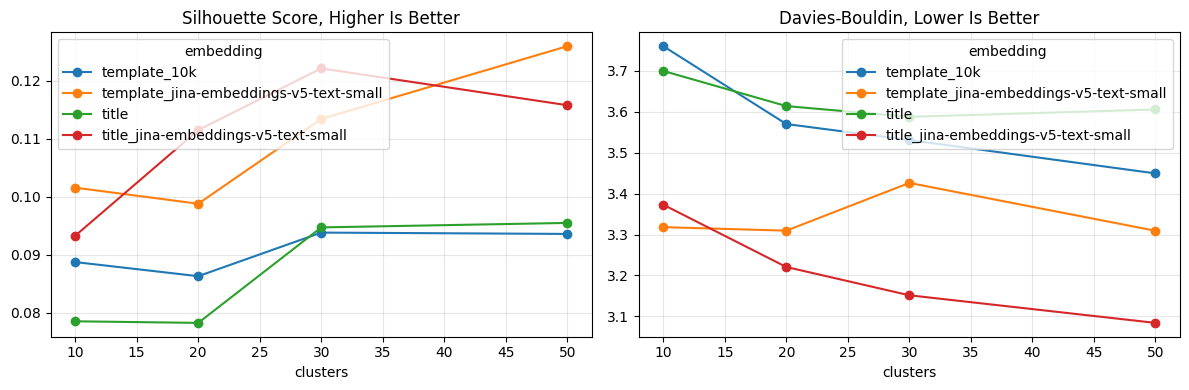

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

metrics.pivot(index="k", columns="embedding", values="silhouette_cosine").plot(
    marker="o",
    ax=axes[0],
    title="Silhouette Score, Higher Is Better",
)
metrics.pivot(index="k", columns="embedding", values="davies_bouldin").plot(
    marker="o",
    ax=axes[1],
    title="Davies-Bouldin, Lower Is Better",
)

for ax in axes:
    ax.grid(alpha=0.3)
    ax.set_xlabel("clusters")

plt.tight_layout()

## UMAP Visual Comparison

UMAP gives a 2D view of each embedding space. Use it to look for coherent groups, but do not over-interpret exact distances.

In [6]:
def umap_projection(matrix, sample_size=5000):
    if len(matrix) > sample_size:
        rng = np.random.default_rng(42)
        sample_idx = np.sort(rng.choice(len(matrix), size=sample_size, replace=False))
        matrix = matrix[sample_idx]
    else:
        sample_idx = np.arange(len(matrix))

    reducer = umap.UMAP(
        n_neighbors=30,
        min_dist=0.05,
        metric="cosine",
        random_state=42,
    )
    coords = reducer.fit_transform(matrix)
    return coords, sample_idx


projections = {}
for name, matrix in embeddings.items():
    coords, sample_idx = umap_projection(matrix)
    projections[name] = {"coords": coords, "sample_idx": sample_idx}

len(projections)

/Users/mahak/work/llmHuggingFace/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/Users/mahak/work/llmHuggingFace/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/Users/mahak/work/llmHuggingFace/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/Users/mahak/work/llmHuggingFace/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


4

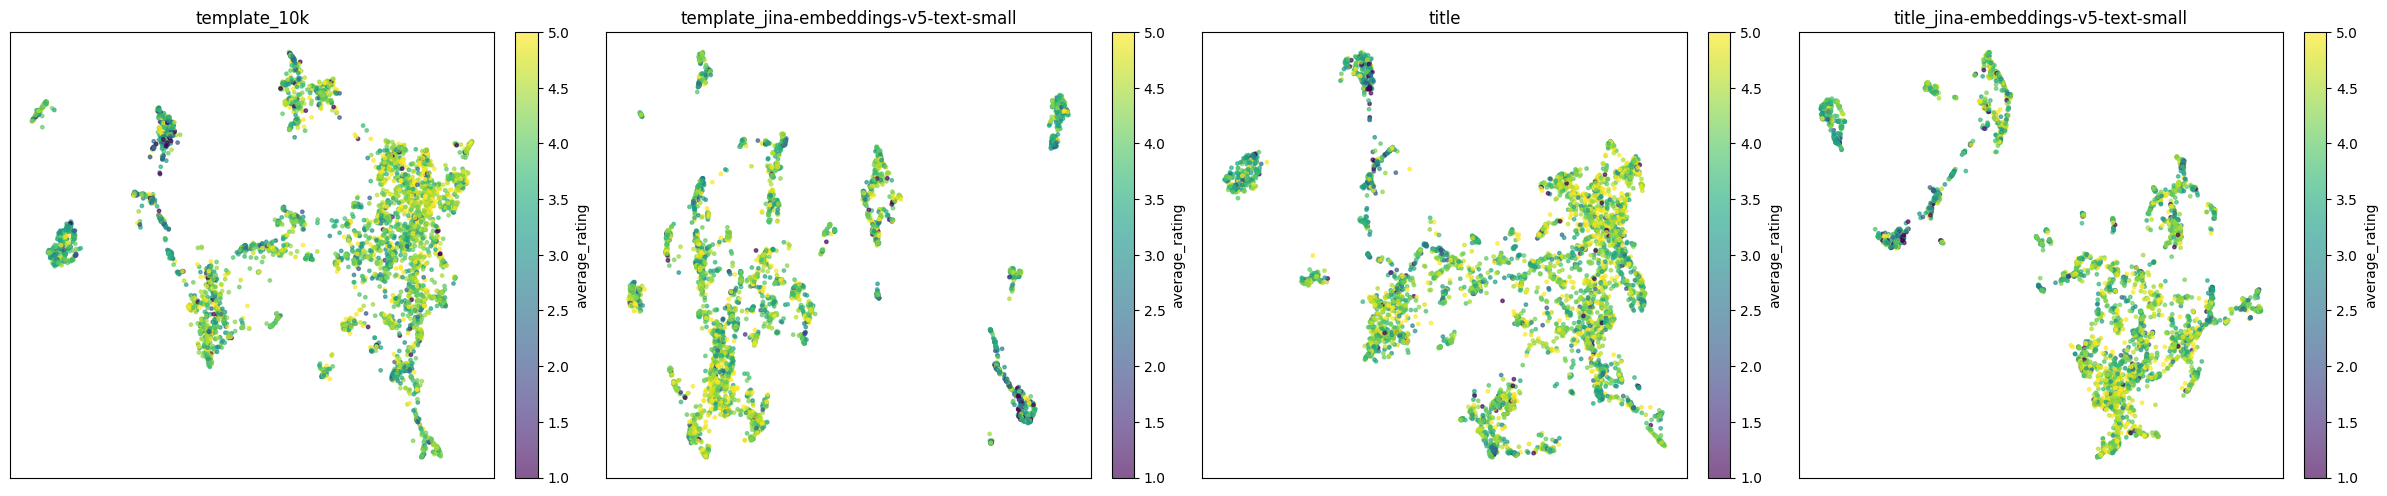

In [7]:
def plot_umaps(color_by="average_rating"):
    count = len(projections)
    fig, axes = plt.subplots(1, count, figsize=(6 * count, 5), squeeze=False)

    for ax, (name, projection) in zip(axes[0], projections.items()):
        coords = projection["coords"]
        sample_idx = projection["sample_idx"]
        colors = metadata.iloc[sample_idx][color_by] if color_by in metadata.columns else None

        scatter = ax.scatter(
            coords[:, 0],
            coords[:, 1],
            c=colors,
            s=6,
            alpha=0.65,
            cmap="viridis" if colors is not None else None,
        )
        ax.set_title(name)
        ax.set_xticks([])
        ax.set_yticks([])
        if colors is not None:
            fig.colorbar(scatter, ax=ax, fraction=0.046, pad=0.04, label=color_by)

    plt.tight_layout()


plot_umaps(color_by="average_rating")

## Nearest-Neighbor Checks

This is the most useful qualitative test. Pick a product row and compare what each embedding thinks is similar.

In [8]:
def nearest_neighbors(name, row_idx, top_k=8):
    matrix = embeddings[name]
    query = matrix[row_idx : row_idx + 1]
    scores = cosine_similarity(query, matrix).ravel()
    neighbor_idx = np.argsort(-scores)[1 : top_k + 1]

    columns = [
        column
        for column in ["title", "store", "price", "average_rating", "rating_number", "embedding_doc"]
        if column in metadata.columns
    ]
    result = metadata.iloc[neighbor_idx][columns].copy()
    result.insert(0, "score", scores[neighbor_idx])
    result.insert(0, "row_idx", neighbor_idx)
    return result


def compare_neighbors(row_idx=0, top_k=5):
    print("Query product:")
    display(metadata.iloc[[row_idx]][["title", "embedding_doc"]])

    for name in embeddings:
        print(f"\nNearest neighbors from {name}")
        display(nearest_neighbors(name, row_idx=row_idx, top_k=top_k))


compare_neighbors(row_idx=0, top_k=5)

Query product:


,title,embedding_doc
0,Skinny Black Narrow Headband in Patent Leather,Product: Skinny Black Narrow Headband in Patent Leather\n Features: Add a classic band of color to you style with our narrow patent leather headband. Squ...



Nearest neighbors from template_10k


,row_idx,score,title,store,price,average_rating,rating_number,embedding_doc
5683,5683,0.692965,Head Bands No Slip Women's Rhinestone Head With Geadband For Teenage Girls And Children With Anti-Slip Teeth Shiny And Shiny Fashion Bangs Female Headwear A...,Honey Bean,None,5.0,2,Product: Head Bands No Slip Women's Rhinestone Head With Geadband For Teenage Girls And Children With Anti-Slip Teeth Shiny And Shiny Fashion Bangs Female H...
4329,4329,0.676496,CoverYourHair Colorful Plastic Headbands- Bulk Headbands (36 Pack Thin Headbands) - Hard Headbands - Hair Accessories,CoverYourHair,24.99,4.0,92,Product: CoverYourHair Colorful Plastic Headbands- Bulk Headbands (36 Pack Thin Headbands) - Hard Headbands - Hair Accessories\n Features: This Party Pac...
4276,4276,0.672286,"MHDGG Knotted Headbands for Women Girls,Glitter Mesh Hairband Head Band for Women Wide Headbands Shiny Sequin Cross Knot Hair Hoop Headband Bezel Hair Acces...",MHDGG,None,4.3,19,"Product: MHDGG Knotted Headbands for Women Girls,Glitter Mesh Hairband Head Band for Women Wide Headbands Shiny Sequin Cross Knot Hair Hoop Headband Bezel H..."
8568,8568,0.660009,Sethexy Fashion Sport Headband Elastic Knotted Hair Band Pure Color Handmade Hair Accessories for Women and Girls(8pcs),Sethexy,None,5.0,1,Product: Sethexy Fashion Sport Headband Elastic Knotted Hair Band Pure Color Handmade Hair Accessories for Women and Girls(8pcs)\n Features: \n Detail...
5914,5914,0.659960,10 Pack Black Hairbands with Button for Women Head Wrap Elastic Hair Band Facemask Holder for Nurses Doctors,RIY,None,4.1,8,Product: 10 Pack Black Hairbands with Button for Women Head Wrap Elastic Hair Band Facemask Holder for Nurses Doctors\n Features: Designed for Doctors an...



Nearest neighbors from template_jina-embeddings-v5-text-small


,row_idx,score,title,store,price,average_rating,rating_number,embedding_doc
5040,5040,0.710132,Silver Embossed Squares Headband Solid Hair band for Women and Girls,Motique Accessories,None,4.0,1,"Product: Silver Embossed Squares Headband Solid Hair band for Women and Girls\n Features: \n Details: {""Age Range (Description)"": ""Adult"", ""Material"":..."
3229,3229,0.670135,FAELBATY 2 Pcs Headbands for Women Knotted Headbands Glitter PU Wide Headbands for Women Cute Hairbands Fashion Knot Headband for Women(Black & Silver),FAELBATY,None,4.2,7,Product: FAELBATY 2 Pcs Headbands for Women Knotted Headbands Glitter PU Wide Headbands for Women Cute Hairbands Fashion Knot Headband for Women(Black & Sil...
1046,1046,0.669126,"LIHELEI Wide Headband for Women, Thick Knitted Headband Fashion Head Wrap in Solid Color Non-slip for Daily Festival Gift-4PCS Black/Red/Maroon/White",LIHELEI,None,3.8,19,"Product: LIHELEI Wide Headband for Women, Thick Knitted Headband Fashion Head Wrap in Solid Color Non-slip for Daily Festival Gift-4PCS Black/Red/Maroon/Whi..."
915,915,0.668081,Silver Crystal Rhinestone 4 Row Elastic Stretch Hair Band Headband,None,9.74,2.7,3,"Product: Silver Crystal Rhinestone 4 Row Elastic Stretch Hair Band Headband\n Features: \n Details: {""Item Weight"": ""0.96 Ounces""}\n Description:"
5428,5428,0.662459,"Mulbozy 3 Pcs Womens Fashion PU Leather Wide Headbands Knot Turban Headbands Elastic Hair Hoops Accessories for Women and Girls, 3 Colors Hair Bands",Mulbozy,None,4.1,6,"Product: Mulbozy 3 Pcs Womens Fashion PU Leather Wide Headbands Knot Turban Headbands Elastic Hair Hoops Accessories for Women and Girls, 3 Colors Hair Band..."



Nearest neighbors from title


,row_idx,score,title,store,price,average_rating,rating_number,embedding_doc
8510,8510,0.682818,RE Style Maleficent Headband Black,RE Style,19.0,3.8,7,"Product: RE Style Maleficent Headband Black\n Features: \n Details: {""Age Range (Description)"": ""Adult"", ""Material"": ""Plastic"", ""Number of Items"": ""1""..."
447,447,0.652855,Black Cone Spike Genuine Leather Top High Quality Cosplay Headband Goth Style,Velvetcrow,16.99,4.2,17,"Product: Black Cone Spike Genuine Leather Top High Quality Cosplay Headband Goth Style\n Features: High Quality Headband Genuine Leather Top 1 1/4"" Pin S..."
1959,1959,0.642462,France Luxe Headband Black One Size,None,None,5.0,3,"Product: France Luxe Headband Black One Size\n Features: \n Details: {""Department"": ""Womens"", ""UPC"": ""639709029816""}\n Description:"
2036,2036,0.603820,Funky Junque Textured Black White String Fabric Rhinestone Elastic Headband,Funky Junque,None,4.5,2,"Product: Funky Junque Textured Black White String Fabric Rhinestone Elastic Headband\n Features: \n Details: {""Package Dimensions"": ""5.9 x 2.8 x 1.1 i..."
3045,3045,0.598317,"Black Metal Headbands for Women, Hair Accessories (6 In, 10 Pack)",Okuna Outpost,None,3.9,12,"Product: Black Metal Headbands for Women, Hair Accessories (6 In, 10 Pack)\n Features: \n Details: {""Age Range (Description)"": ""Adult"", ""Occasion"": ""W..."



Nearest neighbors from title_jina-embeddings-v5-text-small


,row_idx,score,title,store,price,average_rating,rating_number,embedding_doc
1959,1959,0.680269,France Luxe Headband Black One Size,None,None,5.0,3,"Product: France Luxe Headband Black One Size\n Features: \n Details: {""Department"": ""Womens"", ""UPC"": ""639709029816""}\n Description:"
9147,9147,0.677003,Fashion Indian Exotic Boho Vacation Feather Leather Headband Hair Band Belt,Keyzone,None,3.5,26,Product: Fashion Indian Exotic Boho Vacation Feather Leather Headband Hair Band Belt\n Features: \n Details: {}\n Description:
3176,3176,0.659406,Burgundy 2 Inch Velvet Covered Headband with Teeth Women and Girls wide Hair Band,Motique Accessories,None,3.4,2,"Product: Burgundy 2 Inch Velvet Covered Headband with Teeth Women and Girls wide Hair Band\n Features: \n Details: {""Age Range (Description)"": ""Adult""..."
9668,9668,0.658060,BANDED Wide No-Slip Headband (3-Pack),Banded Accessories,None,4.3,4,"Product: BANDED Wide No-Slip Headband (3-Pack)\n Features: \n Details: {""Package Dimensions"": ""9 x 4 x 2 inches; 0.6 Ounces"", ""Item model number"": ""AZ..."
447,447,0.655575,Black Cone Spike Genuine Leather Top High Quality Cosplay Headband Goth Style,Velvetcrow,16.99,4.2,17,"Product: Black Cone Spike Genuine Leather Top High Quality Cosplay Headband Goth Style\n Features: High Quality Headband Genuine Leather Top 1 1/4"" Pin S..."


In [9]:
# Try a few random products and inspect which embedding produces the best neighbors.
rng = np.random.default_rng(7)
for row_idx in rng.choice(len(metadata), size=3, replace=False):
    compare_neighbors(row_idx=int(row_idx), top_k=5)

Query product:


,title,embedding_doc
9447,Yupher Synthetic Brown Wig with Bangs for Black/White Women (242-5),"Product: Yupher Synthetic Brown Wig with Bangs for Black/White Women (242-5)\n Features: \n Details: {""Package Dimensions"": ""13.54 x 9.69 x 2.05 inche..."



Nearest neighbors from template_10k


,row_idx,score,title,store,price,average_rating,rating_number,embedding_doc
5990,5990,0.832299,Red and Black Wigs With Bangs Long Straight Cosplay Wigs Synthetic Split Color Costume Halloween Party Wigs for Women (Black Red (inside)),Sallcks,None,2.0,4,Product: Red and Black Wigs With Bangs Long Straight Cosplay Wigs Synthetic Split Color Costume Halloween Party Wigs for Women (Black Red (inside))\n Fea...
7762,7762,0.810896,Vigorous Yellow Wigs Long Wig With bangs for Women Wigs Cosplay Wig With Bangs 26Inches Straight Wigs,Vigorous,None,3.8,7,"Product: Vigorous Yellow Wigs Long Wig With bangs for Women Wigs Cosplay Wig With Bangs 26Inches Straight Wigs\n Features: \n Details: {""Package Dimen..."
4222,4222,0.805437,Curly Afro Wig With Bangs for Black Women Afro Kinky Curly Wig Ombre Red Synthetic Heat Resistant Short Afro Wigs（14Inch）…,PRETTIEST,None,3.1,14,Product: Curly Afro Wig With Bangs for Black Women Afro Kinky Curly Wig Ombre Red Synthetic Heat Resistant Short Afro Wigs（14Inch）…\n Features: \n Det...
7178,7178,0.799734,YOGFIT Wine Red Wigs with Bangs for Women 15 Inches Synthetic Curly Bob Wig for Girl Natural Looking Wavy Wigs,YOGFIT,None,4.1,6,"Product: YOGFIT Wine Red Wigs with Bangs for Women 15 Inches Synthetic Curly Bob Wig for Girl Natural Looking Wavy Wigs\n Features: \n Details: {""Hair..."
5352,5352,0.797734,Ombre Long Dark Blonde Wig for Women Natural Looking Synthetic Wavy Wigs 170g Full Hair Wig,Annivia,None,3.2,4,"Product: Ombre Long Dark Blonde Wig for Women Natural Looking Synthetic Wavy Wigs 170g Full Hair Wig\n Features: \n Details: {""Is Discontinued By Manu..."



Nearest neighbors from template_jina-embeddings-v5-text-small


...

,row_idx,score,title,store,price,average_rating,rating_number,embedding_doc
5175,5175,0.729764,"Magical Perfecting Base Face Primer Under Foundation Pore Shrink Cream, Soothing Moisturizing, Anti-Aging Wrinkles, Oil Control, Invisible Pore & Smooth Ski...",ASRS,9.99,2.3,4,"Product: Magical Perfecting Base Face Primer Under Foundation Pore Shrink Cream, Soothing Moisturizing, Anti-Aging Wrinkles, Oil Control, Invisible Pore & S..."
2419,2419,0.712838,"Advanced 5 Anti Aging Face Serum - Reduces the look of wrinkles, crow’s feet and forehead lines for a firmer, tighter and younger looking skin - Combines 5 ...",Mac and Mable,None,3.0,5,"Product: Advanced 5 Anti Aging Face Serum - Reduces the look of wrinkles, crow’s feet and forehead lines for a firmer, tighter and younger looking skin - Co..."
9508,9508,0.698338,"Glamology Premier Organic Vitamin C 20% Serum with Hyaluronic Acid and E, Turmeric, Neem and Secret 6 Herbs, Anti-Aging Topical Facial Serum, Repair Sun Dam...",Glamology,None,5.0,1,"Product: Glamology Premier Organic Vitamin C 20% Serum with Hyaluronic Acid and E, Turmeric, Neem and Secret 6 Herbs, Anti-Aging Topical Facial Serum, Repai..."
2021,2021,0.692059,"dermaXgen Instant Wrinkle filler With Peptide, boost collagen & Controls Aging Skin 0.5 FL OZ / 15 ML",DERMAXGEN,None,3.4,38,"Product: dermaXgen Instant Wrinkle filler With Peptide, boost collagen & Controls Aging Skin 0.5 FL OZ / 15 ML\n Features: SKIN SCIENCE: Virtually erase ..."
5949,5949,0.676433,"Flawless Finish Foundation,Liquid Foundation,Flawless Colour Changing Foundation,Liquid Foundation Makeup Face Liquid Foundation Waterproof Concealer Cover ...",TOULIFLY,None,4.0,32,"Product: Flawless Finish Foundation,Liquid Foundation,Flawless Colour Changing Foundation,Liquid Foundation Makeup Face Liquid Foundation Waterproof Conceal..."



Nearest neighbors from title


,row_idx,score,title,store,price,average_rating,rating_number,embedding_doc
5175,5175,0.680833,"Magical Perfecting Base Face Primer Under Foundation Pore Shrink Cream, Soothing Moisturizing, Anti-Aging Wrinkles, Oil Control, Invisible Pore & Smooth Ski...",ASRS,9.99,2.3,4,"Product: Magical Perfecting Base Face Primer Under Foundation Pore Shrink Cream, Soothing Moisturizing, Anti-Aging Wrinkles, Oil Control, Invisible Pore & S..."
6024,6024,0.657015,Huda Beauty Tantour Contour And Bronzer Cream (Rich),HDB Cosmetics,None,2.5,2,Product: Huda Beauty Tantour Contour And Bronzer Cream (Rich)\n Features: \n Details: {}\n Description:
205,205,0.647947,"Vodisa Contour Palette Highlighting Bronzer Powder Kit Matte Corrector Professional Base Foundation Long-Wear, Lightweight, Blends Easily, Highly Pigmente M...",Vodisa,None,4.1,15,"Product: Vodisa Contour Palette Highlighting Bronzer Powder Kit Matte Corrector Professional Base Foundation Long-Wear, Lightweight, Blends Easily, Highly P..."
4596,4596,0.642096,O.TWO.O Magical Concealer Stick Foundation Makeup Full Cover Contour Face Concealer Cream Base Primer Moisturizer Hide Blemish (06wheat),O.TWO.O,None,5.0,1,Product: O.TWO.O Magical Concealer Stick Foundation Makeup Full Cover Contour Face Concealer Cream Base Primer Moisturizer Hide Blemish (06wheat)\n Featu...
1111,1111,0.636658,"TLM Colour Changing Foundation, Flawless Color Changing Foundation Makeup Base Moisturizing Liquid Foundation for Women Girls SPF15, Sunscreen, Non-greasy, ...",God Blomster,None,3.4,350,"Product: TLM Colour Changing Foundation, Flawless Color Changing Foundation Makeup Base Moisturizing Liquid Foundation for Women Girls SPF15, Sunscreen, Non..."



Nearest neighbors from title_jina-embeddings-v5-text-small


,row_idx,score,title,store,price,average_rating,rating_number,embedding_doc
1146,1146,0.764851,Face Make Up Primer & Liquid Foundation Double Tube Long-Lasting Oil Control Soft Moist Hide Pores Isolation Improving Skin Beauty,BEUKING,None,3.2,7,Product: Face Make Up Primer & Liquid Foundation Double Tube Long-Lasting Oil Control Soft Moist Hide Pores Isolation Improving Skin Beauty\n Features: \...
6311,6311,0.750088,BECCA Ever Matte Poreless Priming Perfector Makeup Foundation Primer 0.2 oz,Becca,None,3.7,9,"Product: BECCA Ever Matte Poreless Priming Perfector Makeup Foundation Primer 0.2 oz\n Features: \n Details: {""Brand"": ""Becca"", ""Package Information"":..."
2162,2162,0.742990,"Ownest Women Long Lasting Moisturizing Face Makeup Primer,24K Gold Professional Makeup Cosmetic Foundation Primers-12ml",Ownest,None,3.8,65,"Product: Ownest Women Long Lasting Moisturizing Face Makeup Primer,24K Gold Professional Makeup Cosmetic Foundation Primers-12ml\n Features: \n Detail..."
5175,5175,0.739940,"Magical Perfecting Base Face Primer Under Foundation Pore Shrink Cream, Soothing Moisturizing, Anti-Aging Wrinkles, Oil Control, Invisible Pore & Smooth Ski...",ASRS,9.99,2.3,4,"Product: Magical Perfecting Base Face Primer Under Foundation Pore Shrink Cream, Soothing Moisturizing, Anti-Aging Wrinkles, Oil Control, Invisible Pore & S..."
5269,5269,0.720116,ORIGINS Skin Pore-Perfecting Cooling Primer With Willowherb 75 ml.,Origins,None,4.0,20,"Product: ORIGINS Skin Pore-Perfecting Cooling Primer With Willowherb 75 ml.\n Features: \n Details: {""Brand"": ""Origins"", ""Package Information"": ""Tube""..."
